12.13.	Implement	K-Means	from	scratch.	Test	on	Two	Moons	(K	=	2)	and	three	Gaussian	
blobs.	Visualize	and	comment

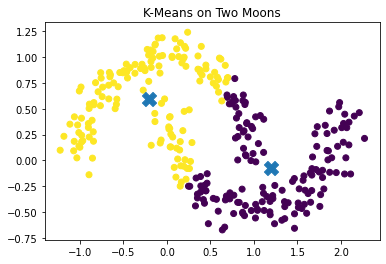

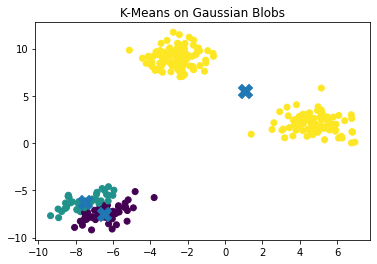

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.datasets import make_blobs

# -------------------------------
# K-Means from Scratch
# -------------------------------

class KMeansScratch:

    def __init__(self,
                 K=2,
                 max_iters=100):

        self.K = K
        self.max_iters = max_iters

    def fit(self, X):

        # Random initialization
        idx = np.random.choice(
            len(X),
            self.K,
            replace=False
        )

        self.centroids = X[idx]

        for _ in range(self.max_iters):

            # Create clusters
            clusters = [[] for _ in range(self.K)]

            # Assign points
            for point in X:

                distances = [
                    np.linalg.norm(
                        point - centroid
                    )
                    for centroid in self.centroids
                ]

                cluster_id = np.argmin(
                    distances
                )

                clusters[cluster_id].append(
                    point
                )

            # Compute new centroids
            new_centroids = []

            for cluster in clusters:

                new_centroids.append(
                    np.mean(cluster, axis=0)
                )

            new_centroids = np.array(
                new_centroids
            )

            # Stop if converged
            if np.allclose(
                self.centroids,
                new_centroids
            ):
                break

            self.centroids = new_centroids

        # Final labels
        self.labels = []

        for point in X:

            distances = [
                np.linalg.norm(
                    point - centroid
                )
                for centroid in self.centroids
            ]

            self.labels.append(
                np.argmin(distances)
            )

# -------------------------------
# Dataset 1 : Two Moons
# -------------------------------

X1, y1 = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=42
)

model1 = KMeansScratch(K=2)

model1.fit(X1)

plt.scatter(
    X1[:,0],
    X1[:,1],
    c=model1.labels
)

plt.scatter(
    model1.centroids[:,0],
    model1.centroids[:,1],
    s=200,
    marker='X'
)

plt.title("K-Means on Two Moons")

plt.show()

# -------------------------------
# Dataset 2 : Gaussian Blobs
# -------------------------------

X2, y2 = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1,
    random_state=42
)

model2 = KMeansScratch(K=3)

model2.fit(X2)

plt.scatter(
    X2[:,0],
    X2[:,1],
    c=model2.labels
)

plt.scatter(
    model2.centroids[:,0],
    model2.centroids[:,1],
    s=200,
    marker='X'
)

plt.title("K-Means on Gaussian Blobs")

plt.show()

12.14.	Implement	K-Means++	initialization.	Compare	J	across	50	runs	for	random	vs	K
Means++.	Plot	histograms.

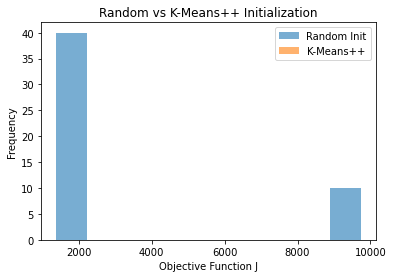

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate dataset
X, y = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

# Store J values
random_J = []
plusplus_J = []

# Run 50 times
for _ in range(50):

    # Random initialization
    km_random = KMeans(
        n_clusters=3,
        init='random',
        n_init=1,
        random_state=None
    )

    km_random.fit(X)

    random_J.append(
        km_random.inertia_
    )

    # K-Means++ initialization
    km_plus = KMeans(
        n_clusters=3,
        init='k-means++',
        n_init=1,
        random_state=None
    )

    km_plus.fit(X)

    plusplus_J.append(
        km_plus.inertia_
    )

# --------------------------------
# Histogram Plot
# --------------------------------

plt.hist(
    random_J,
    bins=10,
    alpha=0.6,
    label='Random Init'
)

plt.hist(
    plusplus_J,
    bins=10,
    alpha=0.6,
    label='K-Means++'
)

plt.xlabel("Objective Function J")

plt.ylabel("Frequency")

plt.title(
    "Random vs K-Means++ Initialization"
)

plt.legend()

plt.show()

12.15.	Generate	data	with	K_true	=	4	clusters.	Run	K-Means	for	K	=	2–7.	Plot	elbow	and	silhouette.	Do	both	identify	K	=	4?

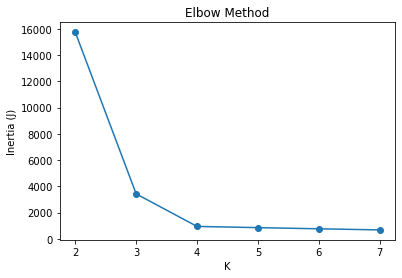

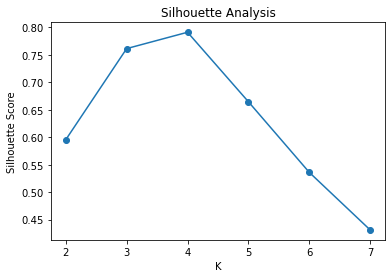

In [3]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1,
    random_state=42
)

Ks = range(2, 8)

# Store values
inertia_values = []
silhouette_values = []

# Run K-Means for different K
for k in Ks:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X)

    # Elbow method value
    inertia_values.append(
        model.inertia_
    )

    # Silhouette score
    score = silhouette_score(
        X,
        labels
    )

    silhouette_values.append(score)

# -------------------------------
# Elbow Plot
# -------------------------------

plt.plot(
    Ks,
    inertia_values,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Inertia (J)")

plt.title("Elbow Method")

plt.show()

# -------------------------------
# Silhouette Plot
# -------------------------------

plt.plot(
    Ks,
    silhouette_values,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

12.16.	Failure	modes:	generate	concentric	circles	and	elongated	Gaussians.	Run	K-Means	with K = 2 on
    each. Explain why it fails.

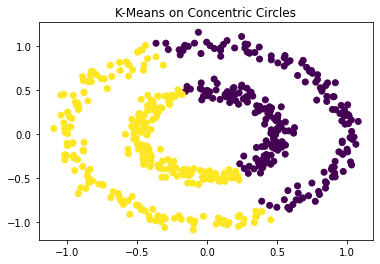

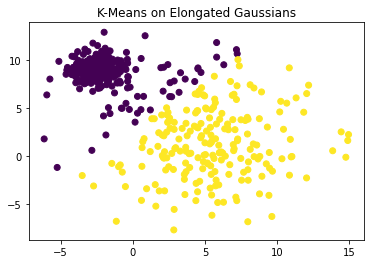

In [5]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# -----------------------------------
# Concentric Circles Dataset
# -----------------------------------

X1, y1 = make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.05,
    random_state=42
)

kmeans1 = KMeans(
    n_clusters=2,
    random_state=42
)

labels1 = kmeans1.fit_predict(X1)

plt.scatter(
    X1[:,0],
    X1[:,1],
    c=labels1
)

plt.title(
    "K-Means on Concentric Circles"
)

plt.show()

# -----------------------------------
# Elongated Gaussian Dataset
# -----------------------------------

X2, y2 = make_blobs(
    n_samples=500,
    centers=2,
    cluster_std=[1,4],
    random_state=42
)

kmeans2 = KMeans(
    n_clusters=2,
    random_state=42
)

labels2 = kmeans2.fit_predict(X2)

plt.scatter(
    X2[:,0],
    X2[:,1],
    c=labels2
)

plt.title(
    "K-Means on Elongated Gaussians"
)

plt.show()

12.17.	Customer	segmentation:	generate	synthetic	data	with	4	features	and	3	segments.	
Standardize,	apply	K-Means	for	K	=	2–6,	choose	K,	interpret	segments. 

K = 2 Silhouette Score = 0.5584431187970683
K = 3 Silhouette Score = 0.7226803781746667
K = 4 Silhouette Score = 0.5674108383809048
K = 5 Silhouette Score = 0.409038462989916
K = 6 Silhouette Score = 0.25176304755581086


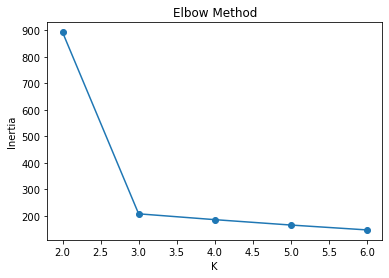

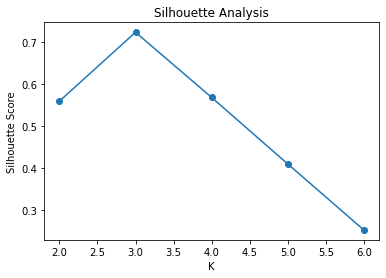

In [17]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------------
# Generate synthetic customer data
# -----------------------------------

X, y = make_blobs(
    n_samples=500,
    centers=3,
    n_features=4,
    cluster_std=1.5,
    random_state=42
)

# -----------------------------------
# Standardization
# -----------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -----------------------------------
# Try K = 2 to 6
# -----------------------------------

Ks = range(2, 7)

inertia_values = []
silhouette_values = []

for k in Ks:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(
        X_scaled
    )

    # Inertia
    inertia_values.append(
        model.inertia_
    )

    # Silhouette Score
    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_values.append(
        score
    )

    print(
        "K =",
        k,
        "Silhouette Score =",
        score
    )

# -----------------------------------
# Elbow Plot
# -----------------------------------

plt.plot(
    Ks,
    inertia_values,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

# -----------------------------------
# Silhouette Plot
# -----------------------------------

plt.plot(
    Ks,
    silhouette_values,
    marker='o'
)

plt.xlabel("K")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

12.18.	K-Medoids	comparison:	implement	PAM	for	K	=	3	on	n	=	30.	Add	3	outliers.	
Compare	centroid	vs	medoid	shift	and	runtimes.

K-Means Centroids:
[[ 0.80093995  5.13254682]
 [25.         25.        ]
 [-6.95160684 -6.77084326]]

K-Medoids Medoids:
[[-2.97261532  8.54855637]
 [ 4.52423055  1.67206599]
 [-7.35880143 -7.06576857]]

K-Means Runtime: 0.02045726776123047
K-Medoids Runtime: 0.004025459289550781


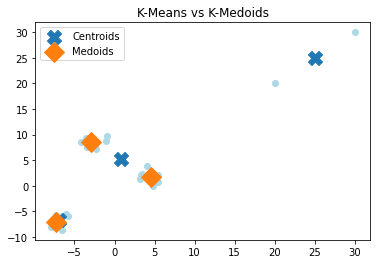

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# -----------------------------------
# Generate dataset
# -----------------------------------

X, y = make_blobs(
    n_samples=30,
    centers=3,
    cluster_std=1,
    random_state=42
)

# Add outliers
outliers = np.array([
    [20,20],
    [25,25],
    [30,30]
])

X_out = np.vstack([X, outliers])

# -----------------------------------
# K-Means
# -----------------------------------

start = time.time()

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_out)

kmeans_time = time.time() - start

# -----------------------------------
# K-Medoids (PAM)
# -----------------------------------

start = time.time()

kmedoids = KMedoids(
    n_clusters=3,
    random_state=42
)

kmedoids.fit(X_out)

kmedoids_time = time.time() - start

# -----------------------------------
# Results
# -----------------------------------

print("K-Means Centroids:")
print(kmeans.cluster_centers_)

print()

print("K-Medoids Medoids:")
print(kmedoids.cluster_centers_)

print()

print("K-Means Runtime:",
      kmeans_time)

print("K-Medoids Runtime:",
      kmedoids_time)

# -----------------------------------
# Visualization
# -----------------------------------

plt.scatter(
    X_out[:,0],
    X_out[:,1],
    c='lightblue'
)

# K-Means centers
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

# K-Medoids centers
plt.scatter(
    kmedoids.cluster_centers_[:,0],
    kmedoids.cluster_centers_[:,1],
    s=200,
    marker='D',
    label='Medoids'
)

plt.legend()

plt.title(
    "K-Means vs K-Medoids"
)

plt.show()